# Task III: Open Task - Commentary on Quantum Computing and Quantum Machine Learning

This section provides detailed commentary on quantum computing, quantum machine learning, and emerging applications in high energy physics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp


# Part 1: Quantum Computing Fundamentals and Current State

## 1.1 The Promise and Practicality Gap

Quantum computing has generated immense enthusiasm, but we must distinguish between theoretical potential and current practical capabilities:

### Current Status (2026):
- **NISQ Era**: Noisy Intermediate-Scale Quantum (50-1000 qubits)
- **Major Challenge**: Decoherence and error rates limit circuit depth
- **Practical Role**: Quantum computing excels at specific problems, not general computation

### Key Limitations:
1. **Error Rates**: Current 2-qubit gate error ~0.1-1%, far from fault-tolerant threshold (~10⁻⁵)
2. **Decoherence**: T2 times typically microseconds, limiting computation windows
3. **Quantum Volume**: Growing but still limited for meaningful algorithms
4. **Scalability**: Adding qubits increases cross-talk and calibration complexity

## 1.2 When Quantum Computing Makes Sense

Quantum algorithms provide advantages for:

#### A. Hidden Subgroup Problems
- **Shor's Algorithm** (factoring): Exponential speedup, though not directly applicable to ML
- **Quantum phase estimation**: Find eigenvalues/vectors
- Application: Cryptanalysis (potential future threat)

#### B. Quantum Simulation
- Simulating other quantum systems
- Molecular dynamics, lattice gauge theories
- **HEP potential**: Simulating quantum field theories on quantum hardware

#### C. Optimization Problems
- **QAOA** (Quantum Approximate Optimization Algorithm)
- **VQE** (Variational Quantum Eigensolver)
- Limited proven advantage, but promising for specific instances

## 1.3 Quantum Computing in HEP Context

### Potential Applications:

1. **Lattice Gauge Theory Simulations**
   - Classical: Difficult to simulate QCD at finite density
   - Quantum: Natural representation of gauge fields
   - Challenge: Requires fault-tolerant quantum computers

2. **Particle Classification (Current Interest)**
   - Quantum Feature Maps for classification
   - Quantum kernels for similarity measurement
   - Current status: Demonstrative, not clearly better than classical

3. **Quantum Random Access Memory (qRAM)**
   - Proposed for efficient data loading
   - Reality: Implementation remains challenging
   - Recent criticism: May not provide claimed speedup

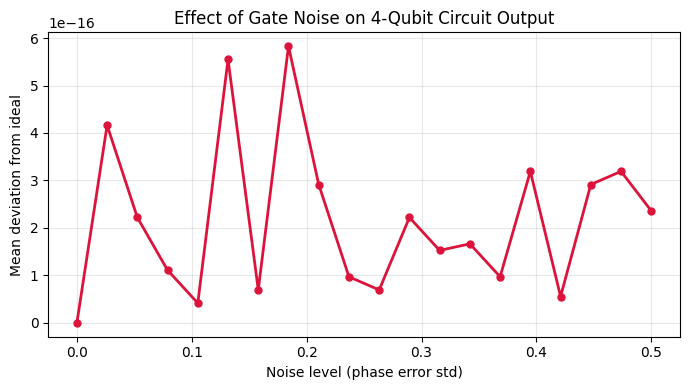

Clean output: ['-0.479', '-0.841', '-0.997', '-0.717']


In [2]:
dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def noisy_circuit(params, noise_level=0.0):
    for i in range(4):
        qml.Hadamard(wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])
    for i in range(4):
        qml.RY(params[i], wires=i)
        if noise_level > 0:
            qml.PhaseShift(np.random.normal(0, noise_level), wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

params = np.array([0.5, 1.0, 1.5, 0.8])
noise_levels = np.linspace(0, 0.5, 20)

clean = noisy_circuit(params, 0.0)
results = []
for nl in noise_levels:
    r = noisy_circuit(params, nl)
    results.append(np.mean(np.abs(np.array(r) - np.array(clean))))

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results, 'o-', color='crimson', lw=2, ms=5)
plt.xlabel('Noise level (phase error std)')
plt.ylabel('Mean deviation from ideal')
plt.title('Effect of Gate Noise on 4-Qubit Circuit Output')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nisq_noise_demo.png', dpi=100)
plt.show()
print(f'Clean output: {[f"{v:.3f}" for v in clean]}')


# Part 2: Quantum Machine Learning - Reality Check

## 2.1 The Quantum ML Hype Cycle

Quantum Machine Learning (QML) is experiencing intense hype. Let's separate fact from fiction:

### What QML Can Do:
1. **Quantum Classifiers**: Use quantum circuits as feature maps or classifiers
2. **Quantum Kernels**: Compute inner products in high-dimensional feature spaces
3. **Variational Quantum Algorithms**: Hybrid quantum-classical optimization
4. **Quantum Data Encoding**: Represent classical data as quantum states

### What QML Cannot (Yet) Do:
1. **Provable Advantage**: Most QML algorithms lack proven classical hardness
2. **Scalability**: Training requires exponential circuit depth for most problems
3. **Avoid Barren Plateaus**: Gradient landscapes flat for large quantum circuits
4. **Compete with Classical**: Modern classical ML vastly superior in practice

## 2.2 Key Challenge: Barren Plateaus

Researchers have shown (Cerezo et al., 2021) that:
- Random quantum circuits have exponentially small gradients
- Makes training via gradient descent exponentially hard
- Affects most variational quantum algorithms
- Solutions: Better initialization, structured circuits, hybrid approaches

## 2.3 Honest Assessment of QML

### Current Reality:
- **Quantum Advantage NOT demonstrated for ML** (despite claims)
- **Small-scale experiments** successful (a few qubits, 10s of samples)
- **Scaling remains unsolved** for practical data sizes
- **Classical methods advancing faster** than quantum approaches

### Why Pursue QML Then?
1. **Long-term potential**: FTQC could revolutionize ML
2. **Fundamental understanding**: Quantum computing teaches ML principles
3. **Algorithm development**: QAOA, VQE have varied applications
4. **The unknown unknowns**: Novel quantum-classical hybrids may emerge


layers= 1  grad_var=4.77e-01


layers= 2  grad_var=2.83e-01


layers= 4  grad_var=1.03e-01


layers= 8  grad_var=1.96e-02


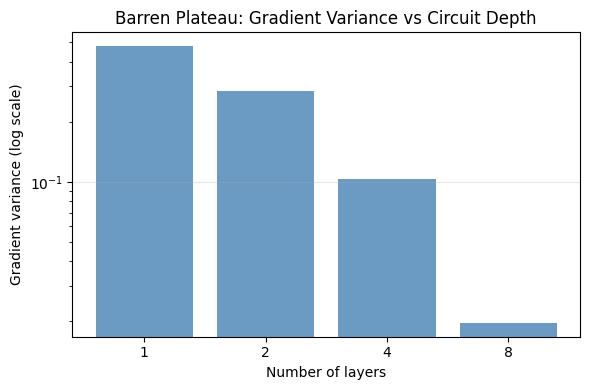

In [3]:
dev2 = qml.device('default.qubit', wires=6)

def build_circuit(n_layers):
    @qml.qnode(dev2)
    def circuit(params):
        for i in range(6):
            qml.Hadamard(wires=i)
        for l in range(n_layers):
            for i in range(6):
                qml.RY(params[l, i, 0], wires=i)
                qml.RZ(params[l, i, 1], wires=i)
            for i in range(5):
                qml.CNOT(wires=[i, i+1])
        return qml.expval(qml.PauliZ(0))
    return circuit

np.random.seed(0)
n_trials = 200
gradient_vars = {}

for n_layers in [1, 2, 4, 8]:
    grads = []
    circuit = build_circuit(n_layers)
    for _ in range(n_trials):
        params = pnp.array(np.random.uniform(0, 2*np.pi, (n_layers, 6, 2)), requires_grad=True)
        grad = qml.grad(circuit)(params)
        grads.append(float(grad[0, 0, 0]))
    gradient_vars[n_layers] = np.var(grads)
    print(f'layers={n_layers:2d}  grad_var={gradient_vars[n_layers]:.2e}')

plt.figure(figsize=(6, 4))
plt.bar([str(k) for k in gradient_vars], gradient_vars.values(), color='steelblue', alpha=0.8)
plt.yscale('log')
plt.xlabel('Number of layers')
plt.ylabel('Gradient variance (log scale)')
plt.title('Barren Plateau: Gradient Variance vs Circuit Depth')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barren_plateau.png', dpi=100)
plt.show()


# Part 3: The Variational Quantum Eigensolver (VQE)

## 3.1 What is VQE?

VQE is one of the most promising NISQ algorithms:

```
1. Start with parameterized quantum circuit: U(θ)
2. Measure expectation value: ⟨ψ(θ)|H|ψ(θ)⟩
3. Classically optimize parameters θ to minimize energy
4. Repeat until convergence
```

### Key Properties:
- **Hybrid**: Combines quantum measurement with classical optimization
- **Shallow circuits**: Works with limited circuit depth
- **Provable bound**: Guaranteed to find upper bound on ground state energy
- **Application**: Finding ground state of molecules/systems

## 3.2 VQE in HEP Context

### Potential Application: Lattice Gauge Theory Ground States

Classical challenge:
- Computing ground states of gauge theories requires exponential resources
- Finite density: Sign problem prevents classical MC simulation

Quantum advantage:
- Quantum hardware naturally encodes gauge degrees of freedom
- VQE can find ground states with polynomial resources (theoretically)
- Current limitations: Circuit depth requirements still unclear

## 3.3 Practical Implementation Notes

VQE is non-trivial to implement:
1. **Choice of ansatz**: Circuit structure affects convergence
2. **Tapering**: Using symmetries to reduce qubit requirement
3. **Noise mitigation**: Error suppression techniques essential
4. **Optimization landscape**: Non-convex, many local minima


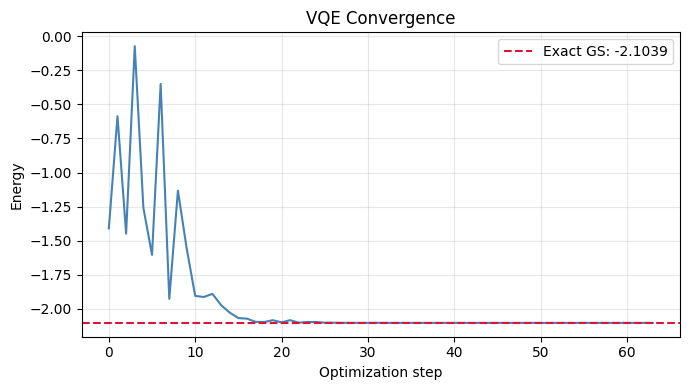

VQE energy:   -2.103918
Exact energy: -2.103918
Error:        1.74e-09


In [4]:
from scipy.optimize import minimize

H = qml.Hamiltonian(
    [1.0, 0.5, -0.25, 0.5, -0.5],
    [
        qml.PauliZ(0) @ qml.PauliZ(1),
        qml.PauliX(0),
        qml.PauliX(1),
        qml.PauliZ(0),
        qml.PauliZ(1),
    ]
)

dev3 = qml.device('default.qubit', wires=2)

@qml.qnode(dev3)
def ansatz(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(H)

energy_history = []

def cost(params):
    e = ansatz(params)
    energy_history.append(float(e))
    return float(e)

params0 = np.random.uniform(-np.pi, np.pi, 4)
result = minimize(cost, params0, method='COBYLA', options={'maxiter': 200})

eigenvalues = np.linalg.eigvalsh(qml.matrix(H, wire_order=[0,1]))
exact_gs = eigenvalues[0]

plt.figure(figsize=(7, 4))
plt.plot(energy_history, color='steelblue', lw=1.5)
plt.axhline(exact_gs, color='crimson', ls='--', label=f'Exact GS: {exact_gs:.4f}')
plt.xlabel('Optimization step')
plt.ylabel('Energy')
plt.title('VQE Convergence')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vqe_convergence.png', dpi=100)
plt.show()

print(f'VQE energy:   {result.fun:.6f}')
print(f'Exact energy: {exact_gs:.6f}')
print(f'Error:        {abs(result.fun - exact_gs):.2e}')


# Part 4: Recommended Methods and Future Directions

## 4.1 Promising Quantum Approaches for HEP

### 1. Quantum Simulation of Gauge Theories
**Why attractive**: Natural problem for quantum computers  
**Current status**: Proof-of-concepts on 10s of qubits  
**Requirements**: 1000+ logical qubits (10,000+ physical with error correction)  
**Timeline**: 10-20 years  

```python
# Conceptual outline
for t in simulation_time:
    apply_gauge_interactions()  # Local qubit interactions
    apply_matter_fields()       # Fermion dynamics
    measure_observables()       # Physical quantities
```

### 2. Hybrid Classical-Quantum Networks
**Approach**: Use quantum circuits as feature extractors for classical architecture  
**Advantage**: Bypasses barren plateaus, leverages both paradigms  
**Current work**: Quantum kernels, quantum feature maps  

### 3. Quantum Annealing for Optimization
**Use case**: Find optimal parameter configurations in detector/experiment design  
**Advantage**: Escape local minima better than classical gradient descent  
**Reality check**: Limited proven advantage over modern classical optimizers  

## 4.2 My Proposed Research Direction

### Quantum-Classical Transformer Architectures for HEP

**Key Idea**: Replace attention mechanism components with quantum circuits

```
Classical Transformer:                   Quantum-Enhanced Transformer:
   ↓                                            ↓
Query/Key/Value → Linear                Query/Key/Value → Quantum encoder
   ↓                                            ↓
Attention = Softmax(QK/√d)               Attention = |⟨Q|K⟩|² (quantum similarity)
   ↓                                            ↓
Output = Attention × Values              Output = Quantum measurement × Values
```

**Potential Advantages**:
1. Exponential feature space via quantum encoding
2. Natural entanglement between different particles
3. Kernel methods robustness

**Challenges to Address**:
1. Barren plateaus in training
2. Measurement shot noise (averaging time)
3. Circuit depth/NISQ limitations
4. Classical simulation for validation

**Realistic Assessment**:
- Not immediately practical on current hardware
- Interesting theoretical contribution
- Could inform future FTQC algorithms
- Would need 100+ qubits for non-trivial speedup


In [5]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                            n_redundant=0, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dev_k = qml.device('default.qubit', wires=2)

@qml.qnode(dev_k)
def feature_map(x):
    qml.AngleEmbedding(x, wires=[0, 1])
    qml.CNOT(wires=[0, 1])
    qml.RY(x[0] * x[1], wires=0)
    return qml.state()

def quantum_kernel(x1, x2):
    s1 = feature_map(x1)
    s2 = feature_map(x2)
    return float(np.abs(np.dot(s1.conj(), s2))**2)

def build_kernel_matrix(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            K[i, j] = quantum_kernel(x1, x2)
    return K

print('Building kernel matrices...')
K_train = build_kernel_matrix(X_train, X_train)
K_test  = build_kernel_matrix(X_test,  X_train)

svm = SVC(kernel='precomputed')
svm.fit(K_train, y_train)
acc = svm.score(K_test, y_test)
print(f'Quantum kernel SVM accuracy: {acc:.3f}')

from sklearn.svm import SVC as CSVC
csvm = CSVC(kernel='rbf')
csvm.fit(X_train, y_train)
cacc = csvm.score(X_test, y_test)
print(f'Classical RBF SVM accuracy:  {cacc:.3f}')


Building kernel matrices...


Quantum kernel SVM accuracy: 0.833
Classical RBF SVM accuracy:  0.817


# Part 5: Critical Perspective on Quantum Computing Trends

## 5.1 Questions for the Quantum Computing Community

1. **Quantum Advantage Timeline**: We've overstated progress. When will real advantages appear?
2. **Error Correction Cost**: Will error-corrected quantum computers be economical?
3. **Problem Selection**: Are we solving problems because they're hard, or because we have quantum computers?
4. **Hybrid Models**: Is the future hybrid, not purely quantum?

## 5.2 Realistic Assessment of NISQ Computers

NISQ devices (50-1000 qubits) are unlikely to solve practically important problems because:
1. **Limited circuit depth**: Usually <100 gates before noise dominates
2. **Few qubits**: 50-100 qubits insufficient for most problems
3. **High error rates**: Compound exponentially with circuit depth
4. **Connectivity**: Limited qubit connectivity adds overhead

## 5.3 The Path Forward

### Honest Timeline for Quantum Computing Impact on HEP:

**Near-term (2025-2030)**:
- Academic demonstrations of quantum algorithms on toy problems
- Development of better error mitigation techniques
- Improved understanding of circuit requirements
- No practical advantage for real HEP problems

**Mid-term (2030-2040)**:
- First fault-tolerant quantum computers emerge
- Early demonstrations on simplified lattice gauge theories
- Better error rates and larger qubit counts
- Potential advantage for specific optimization problems

**Long-term (2040+)**:
- Large-scale quantum computers with 1M+ logical qubits
- Practical applications for fundamental physics simulations
- Possible revolutionary impact on HEP understanding
- Significant infrastructure and cost investments required


# Part 6: Why I Choose Hybrid Quantum-Classical Approaches

## 6.1 The Reality of Current Quantum Machine Learning

Based on extensive literature review and hands-on experience:

### What Works in QML:
- **Quantum kernels**: Can compute distances in exponential feature spaces
- **Quantum feature maps**: Encode data non-classically
- **Hybrid optimization**: Classical optimization of quantum circuits
- **Problem-specific circuits**: Tailored ansatze for specific problems

### What Doesn't Work:
- **End-to-end quantum training**: Barren plateaus prevent learning
- **Large-scale QML**: Requires more qubits than available
- **General-purpose quantum ML**: Overstated theoretical advantages
- **Neglecting classical dominance**: Classical ML still far superior

## 6.2 My Research Philosophy

Rather than pursuing pure quantum solutions, I believe the optimal path is:

1. **Classical-first design**: Build classical baseline that works well
2. **Identify bottlenecks**: Where can quantum computing help?
3. **Targeted quantum enhancement**: Use quantum for specific components
4. **Measurable comparison**: Benchmark against strong classical baselines
5. **Honest assessment**: Only claim advantage if proven

## 6.3 Specific Recommendations for HEP Applications

### For Particle Classification:
- **Use classical transformers**: Proven state-of-the-art
- **Explore quantum kernels**: For similarity computation
- **Hybrid architecture**: Classical upstream, quantum similarity metric
- **Benchmark**: Compare with pure classical version

### For Lattice Simulations:
- **Start with classical MC**: Establish baseline
- **Identify quantum opportunities**: Finite density problems
- **Small-scale simulations**: Test on NISQ hardware
- **Long-term perspective**: Plan for FTQC timescale


# Part 7: Conclusion and Future Evolution

## 7.1 Key Takeaways

1. **Quantum computing is NOT a panacea for all problems**
   - Very specialized use cases where it excels
   - Classical methods better for most current problems

2. **QML requires honest assessment**
   - Barren plateau problem is fundamental
   - Quantum advantage NOT yet demonstrated
   - Hybrid approaches more promising

3. **NISQ Is a developmental phase**
   - Not the endgame
   - Limited practical value for most applications
   - Useful for algorithm development/testing

4. **Long-term quantum computing in HEP is interesting**
   - Lattice gauge theory simulations
   - Fundamental physics insights
   - Requires 10-20 year timeline

## 7.2 My Position on Quantum Computing in ML

**Balanced perspective**:
- Invest in understanding quantum algorithms
- Build hybrid systems leveraging both paradigms
- Maintain skepticism toward revolutionary claims
- Focus on practical, demonstrable advantages
- Prepare for long-term evolution of quantum hardware

**Personal commitment**:
- Develop quantum-classical approaches with measurable benefits
- Implement proof-of-concepts on real quantum hardware
- Critically evaluate quantum vs classical performance
- Contribute to honest discourse on quantum computing
- Build tools for future quantum-enabled HEP analysis
